
## Adam 


<img src="assets/Chap06/TrainADAM.svg" style="filter: invert(1);" width="100%">

Adaptive moment estimation (Adam). 

a) This loss function changes quickly in the vertical direction but slowly in the horizontal direction. If we run full-batch gradient descent with a learning rate that makes good progress in the vertical direction, then the algorithm takes a long time to reach the final horizontal
position. 

b) If the learning rate is chosen so that the algorithm makes good progress in the horizontal direction, it overshoots in the vertical direction and becomes unstable. 

c) A straightforward approach is to move a fixed distance along each axis at each step so that we move downhill in both directions. This is accomplished by normalizing the gradient magnitude and retaining only the sign. However, this does not usually converge to the exact minimum but instead oscillates back and forth around it (here between the last two points). 

d) The Adam algorithm uses momentum in both the estimated gradient and the normalization
term, which creates a smoother path.

---


### 1. Normalized Gradients

Gradient descent with a fixed step size has the following undesirable property: 

it makes large adjustments to parameters associated with large gradients (where perhaps we
should be more cautious) and small adjustments to parameters associated with small
gradients (where perhaps we should explore further). 

When the gradient of the loss surface is much steeper in one direction than another, it is diﬀicult to choose a learning rate that 

(i) makes good progress in both directions and 
(ii) is stable (figures 6.9a–b).

A straightforward approach is to normalize the gradients so that we move a fixed
distance (governed by the learning rate) in each direction. To do this, we first measure
the gradient $\mathbf{m}_{t+1}$ and the pointwise squared gradient $\mathbf{v}_{t+1}$:

\begin{eqnarray}
  \mathbf{m}_{t+1} &\leftarrow& \frac{\partial L[\boldsymbol\phi_{t}]}{\partial \boldsymbol\phi}\nonumber \\
  \mathbf{v}_{t+1} &\leftarrow& \left(\frac{\partial L[\boldsymbol\phi_{t}]}{\partial \boldsymbol\phi}\right)^2.
 \end{eqnarray}

Then we apply the update rule:

\begin{eqnarray}
 \boldsymbol\phi_{t+1} &\leftarrow & \boldsymbol\phi_{t} - \alpha \cdot \frac{\mathbf{m}_{t+1}}{\sqrt{\mathbf{v}_{t+1}}+\epsilon},
 \end{eqnarray}

where the square root and division are both pointwise, $\alpha$ is the learning rate, and $\epsilon$ is a small constant that prevents division by zero when the gradient magnitude is zero. 

<mark>The term $\mathbf{v}_{t+1}$ is the squared gradient, and the positive root of this is used to normalize the gradient itself, so all that remains is the sign in each coordinate direction. 

The result is that the algorithm moves a fixed distance α along each coordinate, where the direction
is determined by whichever way is downhill</mark> (figure 6.9c). 

For example, if $\mathbf{m_{t+1}} = \begin{pmatrix} 3 \\ -2 \\ 5 \end{pmatrix}$, the $\mathbf{v}_{t+1} = \begin{pmatrix} 9 \\ 4 \\ 25 \end{pmatrix}$ and $\frac{\mathbf{m}_{t+1}}{\sqrt{\mathbf{v}_{t+1}}} = \begin{pmatrix} 1 \\ -1 \\ 1 \end{pmatrix}$.

This simple algorithm makes good progress in both directions but will not converge unless it happens to land exactly at the minimum. Instead, it will bounce back and forth around the minimum.

### 2. Momentum 

Adaptive moment estimation, or Adam, takes this idea and adds momentum to both
the estimate of the gradient and the squared gradient:


\begin{eqnarray}\label{eq:train_adam}
  \mathbf{m}_{t+1} &\leftarrow& \beta \cdot \mathbf{m}_{t} + (1-\beta) \frac{\partial L[\boldsymbol\phi_{t}]}{\partial \boldsymbol\phi}\nonumber \\
  \mathbf{v}_{t+1} &\leftarrow& \gamma \cdot \mathbf{v}_{t} + (1-\gamma) \left(\frac{\partial L[\boldsymbol\phi_{t}]}{\partial \boldsymbol\phi}\right)^2,
 \end{eqnarray}

where $\beta$ and $\gamma$ are the momentum coeﬀicients for the two statistics.

Using momentum is equivalent to taking a weighted average over the history of each
of these statistics. At the start of the procedure, all the previous measurements are
effectively zero, resulting in unrealistically small estimates. 

Note that $\beta$ controls the memory of direction in the momentum term, while $\gamma$ controls the memory of the magnitude of the squared gradient. This is because $\beta$ keeps the orientation by not changing the sign while $\gamma$ gets rid of of the sign and hence the direction retaining only the magnitude.

### 3. Adaptive update

Consequently, we modify these statistics using the rule:

\begin{eqnarray}\label{eq:train_adam_modify}
 \tilde{\mathbf{m}}_{t+1} &\leftarrow & \frac{\mathbf{m}_{t+1}}{1-\beta^{t+1}}\nonumber \\
 \tilde{\mathbf{v}}_{t+1} &\leftarrow & \frac{\mathbf{v}_{t+1}}{1-\gamma^{t+1}}.
 \end{eqnarray}

 Since $\beta$ and $\gamma$ are in the range [0,1), the terms with exponents $t+ 1$ become smaller
with each time step, the denominators become closer to one, and this modification has
a diminishing effect.
Finally, we update the parameters as before, but with the modified terms:

\begin{eqnarray}
 \boldsymbol\phi_{t+1} &\leftarrow & \boldsymbol\phi_{t} - \alpha\cdot\frac{ \tilde{\mathbf{m}}_{t+1}}{\sqrt{\tilde{\mathbf{v}}_{t+1}}+\epsilon}.
 \end{eqnarray}

The result is an algorithm that can converge to the overall minimum and makes good
progress in every direction in the parameter space. 

### 4. Mini-batch setting

Note that Adam is usually used in a
stochastic setting where the gradients and their squares are computed from mini-batches:

\begin{eqnarray}\label{eq:train_adam_final}
  \mathbf{m}_{t+1} &\leftarrow& \beta \cdot \mathbf{m}_{t} + (1-\beta) \sum_{i\in\mathcal{B}_{t}}\frac{\partial \ell_i[\boldsymbol\phi_{t}]}{\partial \boldsymbol\phi}\nonumber \\
  \mathbf{v}_{t+1} &\leftarrow& \gamma \cdot \mathbf{v}_{t} + (1-\gamma) \left(\sum_{i\in\mathcal{B}_{t}}\frac{\partial \ell_i[\boldsymbol\phi_{t}]}{\partial \boldsymbol\phi}\right)^2,
 \end{eqnarray}

 and so the trajectory is noisy in practice.
As we shall see in chapter 7, the gradient magnitudes of neural network parameters
can depend on their depth in the network. Adam helps compensate for this tendency
and balances out changes across the different layers. In practice, Adam also has the
advantage of being less sensitive to the initial learning rate because it avoids situations
like those in figures 6.9a–b, so it doesn’t need complex learning rate schedules.

In [16]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.style.use('dark_background')
     

# Define function that we wish to find the minimum of (normally would be defined implicitly by data and loss)
def loss(phi0, phi1):
    height = np.exp(-0.5 * (phi1 * phi1)*4.0)
    height = height * np. exp(-0.5* (phi0-0.7) *(phi0-0.7)/4.0)
    return 1.0-height

# Compute the gradients of this function (for simplicity, I just used finite differences)
def get_loss_gradient(phi0, phi1):
    delta_phi = 0.00001;
    gradient = np.zeros((2,1));
    gradient[0] = (loss(phi0+delta_phi/2.0, phi1) - loss(phi0-delta_phi/2.0, phi1))/delta_phi
    gradient[1] = (loss(phi0, phi1+delta_phi/2.0) - loss(phi0, phi1-delta_phi/2.0))/delta_phi
    return gradient[:,0];

# Compute the loss function at a range of values of phi0 and phi1 for plotting
def get_loss_function_for_plot():
  grid_values = np.arange(-1.0,1.0,0.01);
  phi0mesh, phi1mesh = np.meshgrid(grid_values, grid_values)
  loss_function = np.zeros((grid_values.size, grid_values.size))
  for idphi0, phi0 in enumerate(grid_values):
      for idphi1, phi1 in enumerate(grid_values):
          loss_function[idphi0, idphi1] = loss(phi1,phi0)
  return loss_function, phi0mesh, phi1mesh

In [17]:
# Define fancy colormap
my_colormap_vals_hex =('2a0902', '2b0a03', '2c0b04', '2d0c05', '2e0c06', '2f0d07', '300d08', '310e09', '320f0a', '330f0b', '34100b', '35110c', '36110d', '37120e', '38120f', '39130f', '3a1410', '3b1411', '3c1511', '3d1612', '3e1613', '3f1713', '401714', '411814', '421915', '431915', '451a16', '461b16', '471b17', '481c17', '491d18', '4a1d18', '4b1e19', '4c1f19', '4d1f1a', '4e201b', '50211b', '51211c', '52221c', '53231d', '54231d', '55241e', '56251e', '57261f', '58261f', '592720', '5b2821', '5c2821', '5d2922', '5e2a22', '5f2b23', '602b23', '612c24', '622d25', '632e25', '652e26', '662f26', '673027', '683027', '693128', '6a3229', '6b3329', '6c342a', '6d342a', '6f352b', '70362c', '71372c', '72372d', '73382e', '74392e', '753a2f', '763a2f', '773b30', '783c31', '7a3d31', '7b3e32', '7c3e33', '7d3f33', '7e4034', '7f4134', '804235', '814236', '824336', '834437', '854538', '864638', '874739', '88473a', '89483a', '8a493b', '8b4a3c', '8c4b3c', '8d4c3d', '8e4c3e', '8f4d3f', '904e3f', '924f40', '935041', '945141', '955242', '965343', '975343', '985444', '995545', '9a5646', '9b5746', '9c5847', '9d5948', '9e5a49', '9f5a49', 'a05b4a', 'a15c4b', 'a35d4b', 'a45e4c', 'a55f4d', 'a6604e', 'a7614e', 'a8624f', 'a96350', 'aa6451', 'ab6552', 'ac6552', 'ad6653', 'ae6754', 'af6855', 'b06955', 'b16a56', 'b26b57', 'b36c58', 'b46d59', 'b56e59', 'b66f5a', 'b7705b', 'b8715c', 'b9725d', 'ba735d', 'bb745e', 'bc755f', 'bd7660', 'be7761', 'bf7862', 'c07962', 'c17a63', 'c27b64', 'c27c65', 'c37d66', 'c47e67', 'c57f68', 'c68068', 'c78169', 'c8826a', 'c9836b', 'ca846c', 'cb856d', 'cc866e', 'cd876f', 'ce886f', 'ce8970', 'cf8a71', 'd08b72', 'd18c73', 'd28d74', 'd38e75', 'd48f76', 'd59077', 'd59178', 'd69279', 'd7937a', 'd8957b', 'd9967b', 'da977c', 'da987d', 'db997e', 'dc9a7f', 'dd9b80', 'de9c81', 'de9d82', 'df9e83', 'e09f84', 'e1a185', 'e2a286', 'e2a387', 'e3a488', 'e4a589', 'e5a68a', 'e5a78b', 'e6a88c', 'e7aa8d', 'e7ab8e', 'e8ac8f', 'e9ad90', 'eaae91', 'eaaf92', 'ebb093', 'ecb295', 'ecb396', 'edb497', 'eeb598', 'eeb699', 'efb79a', 'efb99b', 'f0ba9c', 'f1bb9d', 'f1bc9e', 'f2bd9f', 'f2bfa1', 'f3c0a2', 'f3c1a3', 'f4c2a4', 'f5c3a5', 'f5c5a6', 'f6c6a7', 'f6c7a8', 'f7c8aa', 'f7c9ab', 'f8cbac', 'f8ccad', 'f8cdae', 'f9ceb0', 'f9d0b1', 'fad1b2', 'fad2b3', 'fbd3b4', 'fbd5b6', 'fbd6b7', 'fcd7b8', 'fcd8b9', 'fcdaba', 'fddbbc', 'fddcbd', 'fddebe', 'fddfbf', 'fee0c1', 'fee1c2', 'fee3c3', 'fee4c5', 'ffe5c6', 'ffe7c7', 'ffe8c9', 'ffe9ca', 'ffebcb', 'ffeccd', 'ffedce', 'ffefcf', 'fff0d1', 'fff2d2', 'fff3d3', 'fff4d5', 'fff6d6', 'fff7d8', 'fff8d9', 'fffada', 'fffbdc', 'fffcdd', 'fffedf', 'ffffe0')
my_colormap_vals_dec = np.array([int(element,base=16) for element in my_colormap_vals_hex])
r = np.floor(my_colormap_vals_dec/(256*256))
g = np.floor((my_colormap_vals_dec - r *256 *256)/256)
b = np.floor(my_colormap_vals_dec - r * 256 *256 - g * 256)
my_colormap_vals = np.vstack((r,g,b)).transpose()/255.0
my_colormap = ListedColormap(my_colormap_vals)

# Plotting function
def draw_function(phi0mesh, phi1mesh, loss_function, my_colormap, opt_path):
    fig = plt.figure();
    ax = plt.axes();
    fig.set_size_inches(7,7)
    ax.contourf(phi0mesh, phi1mesh, loss_function, 256, cmap=my_colormap);
    ax.contour(phi0mesh, phi1mesh, loss_function, 20, colors=['#80808080'])
    ax.plot(opt_path[0,:], opt_path[1,:],'-', color='#a0d9d3ff')
    ax.plot(opt_path[0,:], opt_path[1,:],'.', color='#a0d9d3ff',markersize=10)
    ax.set_xlabel(r"")
    ax.set_ylabel(r"")
    plt.show()

In [18]:
# Simple fixed step size gradient descent
def grad_descent(start_posn, n_steps, alpha):
    grad_path = np.zeros((2, n_steps+1));
    grad_path[:,0] = start_posn[:,0];
    for c_step in range(n_steps):
        this_grad = get_loss_gradient(grad_path[0,c_step], grad_path[1,c_step]);
        grad_path[:,c_step+1] = grad_path[:,c_step] - alpha * this_grad
    return grad_path;

We'll start by running gradient descent with a fixed step size for this loss function.

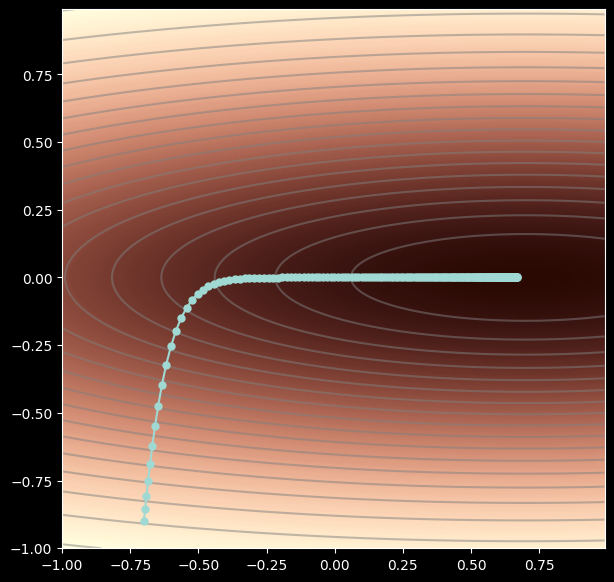

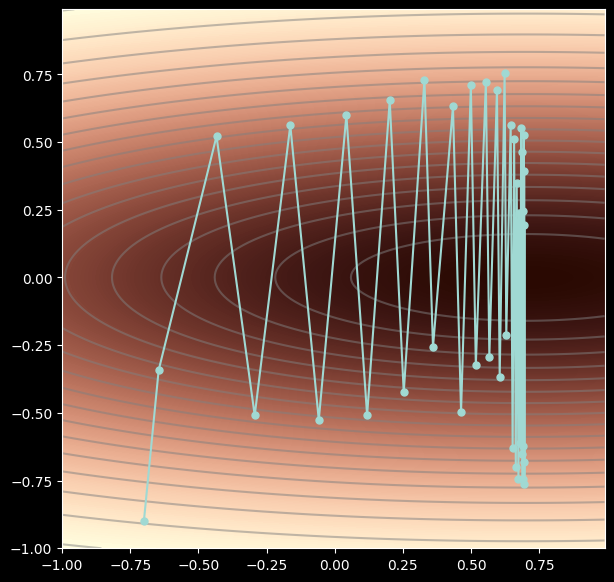

In [19]:
loss_function, phi0mesh, phi1mesh = get_loss_function_for_plot() ;

start_posn = np.zeros((2,1));
start_posn[0,0] = -0.7; start_posn[1,0] = -0.9

# Run gradient descent
grad_path1 = grad_descent(start_posn, n_steps=200, alpha = 0.08)
draw_function(phi0mesh, phi1mesh, loss_function, my_colormap, grad_path1)
grad_path2 = grad_descent(start_posn, n_steps=40, alpha= 1.0)
draw_function(phi0mesh, phi1mesh, loss_function, my_colormap, grad_path2)

Because the function changes much faster in 
 than in 
, there is no great step size to choose. If we set the step size so that it makes sensible progress in the 
 direction, then it takes many iterations to converge. If we set the step size so that we make sensible progress in the 
 direction, then the path oscillates in the 
 direction.

This motivates Adam. At the core of Adam is the idea that we should just determine which way is downhill along each axis (i.e. left/right for 
 or up/down for 
) and move a fixed distance in that direction.

In [20]:
def normalized_gradients(start_posn, n_steps, alpha,  epsilon=1e-20):
    grad_path = np.zeros((2, n_steps+1));
    grad_path[:,0] = start_posn[:,0];
    for c_step in range(n_steps):

        m = get_loss_gradient(grad_path[0,c_step], grad_path[1,c_step]);

        v = m**2
        v = v + epsilon
        m = m / np.sqrt(v)
        alpha_m = alpha * m
        grad_path[:,c_step+1] = grad_path[:,c_step] - alpha_m


    return grad_path;

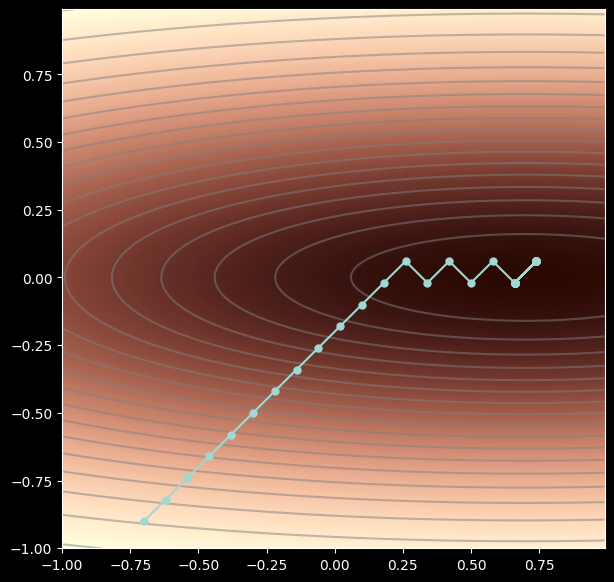

In [21]:
# Let's try out normalized gradients
start_posn = np.zeros((2,1));
start_posn[0,0] = -0.7; start_posn[1,0] = -0.9

# Run gradient descent
grad_path1 = normalized_gradients(start_posn, n_steps=40, alpha = 0.08)
draw_function(phi0mesh, phi1mesh, loss_function, my_colormap, grad_path1)

This moves towards the minimum at a sensible speed, but we never actually converge -- the solution just bounces back and forth between the last two points. To make it converge, we add momentum to both the estimates of the gradient and the pointwise squared gradient. We also modify the statistics by a factor that depends on the time to make sure the progress is not slow to start with.

In [22]:
def adam(start_posn, n_steps, alpha,  beta=0.9, gamma=0.99, epsilon=1e-20):
    grad_path = np.zeros((2, n_steps+1));
    grad_path[:,0] = start_posn[:,0];
    m = np.zeros_like(grad_path[:,0])
    v = np.zeros_like(grad_path[:,0])
    for c_step in range(n_steps):
        # Measure the gradient
        grad = get_loss_gradient(grad_path[0,c_step], grad_path[1,c_step])

        m = beta * m + (1 - beta) * grad

        v = gamma * v + (1 - gamma) * (grad**2)

        m_tilde = m / (1 - np.power(beta, c_step+1))
        v_tilde = v / (1 - np.power(gamma, c_step+1))


        grad_path[:,c_step+1] = grad_path[:,c_step] - alpha * m_tilde / (np.sqrt(v_tilde) + epsilon)

    return grad_path;

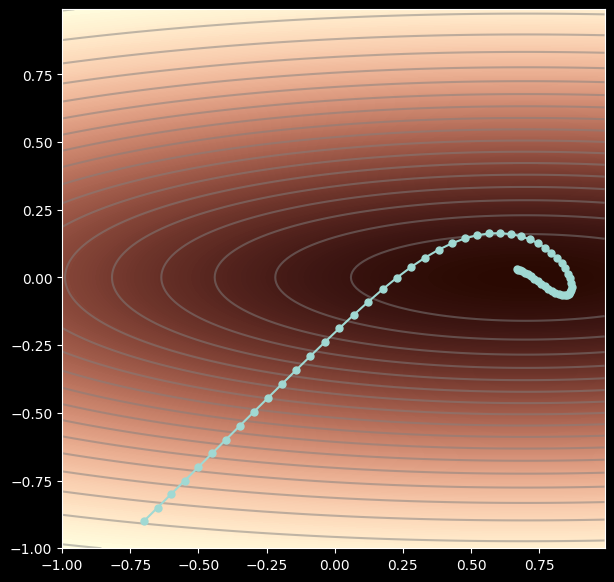

In [23]:
# Let's try out our Adam algorithm
start_posn = np.zeros((2,1));
start_posn[0,0] = -0.7; start_posn[1,0] = -0.9

# Run gradient descent
grad_path1 = adam(start_posn, n_steps=60, alpha = 0.05)
draw_function(phi0mesh, phi1mesh, loss_function, my_colormap, grad_path1)